In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 72
import numpy as np
import sys

import torch
from torch import nn, optim
import torchvision

print(f'PyTorch version= {torch.__version__}')
print(f'torchvision version= {torchvision.__version__}')
print(f'CUDA available= {torch.cuda.is_available()}')

# Set the GPU to device 0
Device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

PyTorch version= 2.10.0
torchvision version= 0.25.0
CUDA available= False


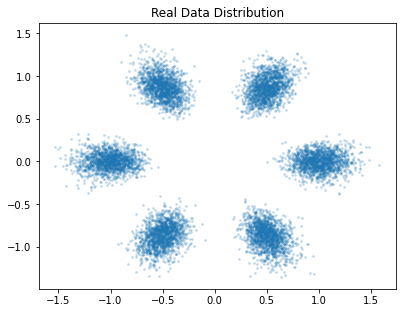

In [8]:
N_DATA= 10000

def synth_data(n=N_DATA, nclasses=6, var=0.10):
    angles = np.linspace(0, 2 * np.pi, nclasses, endpoint=False)  # angles for the unit circle
    centers = np.array([[np.cos(angle), np.sin(angle)] for angle in angles])  # class centers

    gdata = []
    for c, center in enumerate(centers):
        # generate points around the center
        points = np.random.normal(loc=center, scale=var, size=(n//nclasses, 2))
        norms = np.linalg.norm(points, axis=1, keepdims=True)
        points = points * np.abs(norms)**0.5  # stretch large values
        # labels = np.full((n/nclasses, 1), class_label)
        points = points.reshape(-1, 2).astype(np.float32)
        gdata += [np.hstack((points, ))]
    gdata = np.vstack(gdata)  # combine all classes
    return gdata

Realdata = synth_data()
plt.scatter(Realdata[:,0], Realdata[:,1], s=3, alpha=0.2)
plt.title("Real Data Distribution")
plt.show()

In [9]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 1024

dset = TensorDataset(torch.tensor(Realdata))
Dloader_gan = DataLoader(dset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=8, pin_memory=True, prefetch_factor=4, persistent_workers=True)

In [10]:
Z_DIM= 4

class Generator(nn.Module):
    def __init__(self, input_dim=Z_DIM, output_dim=1):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
    def forward(self, _x):
        return self.model(_x)

class Discriminator(nn.Module):
    def __init__(self, input_dim=1):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, _x):
        return self.model(_x)

class Critic(nn.Module):
    def __init__(self, input_dim=1):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1)
            # no activation
        )
    def forward(self, _x):
        return self.model(_x)

class GAN:
    def __init__(self, epochs=100, eta=0.001, info=False):
        self.epochs, self.eta, self.info = epochs, eta, info
        self.criterion = nn.BCELoss()
        self.netD, self.netG, self.optimizerD, self.optimizerG = None, None, None, None
        self.labels_real, self.labels_fake, self.labels_gen = None, None, None
        self.LossDReal, self.LossDFake, self.LossG = None, None, None
        self.LabelReal = 1
        self.LabelFake = 0

    def initDG(self):  # 2 dimensional
        self.netD = Discriminator(input_dim=2).to(Device)
        self.netG = Generator(output_dim=2).to(Device)
        # Optimizers
        self.optimizerD = optim.Adam(self.netD.parameters(), lr=self.eta)
        self.optimizerG = optim.Adam(self.netG.parameters(), lr=self.eta)
    
    def execD(self, _x_real):
        bs = _x_real.size(0)
        self.netD.zero_grad()
        
        self.labels_real = torch.full((bs,1), self.LabelReal, dtype=torch.float, device=Device)
        y_real = self.netD(_x_real)
        loss_D_real = self.criterion(y_real, self.labels_real)

        z_noise = torch.randn(bs, Z_DIM, device=Device)
        x_fake = self.netG(z_noise)
        self.labels_fake = torch.full((bs,1), self.LabelFake, dtype=torch.float, device=Device)
        y_fake = self.netD(x_fake.detach())
        loss_D_fake = self.criterion(y_fake, self.labels_fake)
        
        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        self.optimizerD.step()
        return x_fake, loss_D_real, loss_D_fake, bs
    
    def execG(self, _bs):
        self.netG.zero_grad()
        self.labels_gen = torch.full((_bs,1), self.LabelReal, dtype=torch.float, device=Device)
        z_noise = torch.randn(_bs, Z_DIM, device=Device)
        x_fake = self.netG(z_noise)
        y_fake_r = self.netD(x_fake)
        loss_G = self.criterion(y_fake_r, self.labels_gen)
        loss_G.backward()
        self.optimizerG.step()
        return loss_G

    def fit(self, _train_dl):
        self.initDG()

        self.LossDReal, self.LossDFake, self.LossG = [], [], []

        for e in range(self.epochs):
            lossDr, lossDf, lossG = [], [], []
            for data in _train_dl:
                x_real = data[0].to(Device)

                _, loss_D_real, loss_D_fake, bs = self.execD(x_real)
                loss_G = self.execG(bs)

                if self.info:
                    sys.stderr.write("\r{:03d}/{:3d} | LossDr: {:6.5f} | lossDf: {:6.5f} | lossG: {:6.5f}".format(
                        e+1, self.epochs, loss_D_real.mean().item(), loss_D_fake.mean().item(), loss_G.mean().item()))
                    sys.stderr.flush()

                lossDr += [loss_D_real.mean().item()]
                lossDf += [loss_D_fake.mean().item()]
                lossG += [loss_G.mean().item()]

            self.LossDReal += [(np.array(lossDr).mean(), np.array(lossDr).std())]
            self.LossDFake += [(np.array(lossDf).mean(), np.array(lossDf).std())]
            self.LossG += [(np.array(lossG).mean(), np.array(lossG).std())]

class WassersteinLoss(nn.Module):
    def __init__(self):
        super().__init__()
    @classmethod
    def forward(cls, _input, _target):  # input is prediction, target is labels
        if _target is None:  # shortcut using 1 and -1
            return -torch.mean(_input)
        return -torch.mean(_input*_target)

class WGAN(GAN):
    def __init__(self, epochs=100, eta=0.001, info=False, n_critic=5, clipw=0.05):
        super().__init__(epochs, eta, info)
        self.n_critic, self.clipw = n_critic, clipw
        self.criterion = WassersteinLoss()
        self.LabelFake = -1

    def initDG(self):
        self.netD = Critic(input_dim=2).to(Device)
        self.netG = Generator(output_dim=2).to(Device)
        self.optimizerD = optim.RMSprop(self.netD.parameters(), lr=self.eta)
        self.optimizerG = optim.RMSprop(self.netG.parameters(), lr=self.eta)

    def execD(self, _x_real):
        bs = _x_real.size(0)
        x_fake, loss_D_real, loss_D_fake = None, None, None
        for _ in range(self.n_critic):
            self.netD.zero_grad()
            y_real = self.netD(_x_real)
            loss_D_real = self.criterion(y_real, None)

            z_noise = torch.randn(bs, Z_DIM, device=Device)
            x_fake = self.netG(z_noise)
            y_fake = self.netD(x_fake.detach())
            loss_D_fake = -self.criterion(y_fake, None)  # careful with coefficient since fake is -1

            loss_D = loss_D_real + loss_D_fake
            loss_D.backward()
            self.optimizerD.step()

            for p in self.netD.parameters():
                p.data.clamp_(-self.clipw, self.clipw)
        
        return x_fake, loss_D_real, loss_D_fake, bs

    def execG(self, _bs):
        self.netG.zero_grad()
        z_noise = torch.randn(_bs, Z_DIM, device=Device)
        x_fake = self.netG(z_noise)
        y_fake_r = self.netD(x_fake)  # use fresh x_fake
        loss_G = self.criterion(y_fake_r, None)
        loss_G.backward()
        self.optimizerG.step()
        return loss_G

In [11]:
def gen_plot(_ax, _netG):
    _netG.eval()
    with torch.no_grad():
        z_noise = torch.randn(N_DATA, Z_DIM, device=Device)
        gendata = _netG(z_noise).cpu().numpy()
    _ax.scatter(gendata[:,0], gendata[:,1], s=3, alpha=0.2)

In [12]:
%%time

gan = GAN(epochs=3000, eta=0.001, info=True)
gan.fit(Dloader_gan)

/Users/jeff/.local/share/mamba/envs/jhu-genai-mod9/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
3000/3000 | LossDr: 0.65389 | lossDf: 0.72851 | lossG: 0.66285

CPU times: user 1min 44s, sys: 2min 13s, total: 3min 57s
Wall time: 3min 47s


In [13]:
%%time

wgan = WGAN(epochs=3000, eta=0.001, info=True, n_critic=5)
wgan.fit(Dloader_gan)

3000/3000 | LossDr: 0.06455 | lossDf: -0.06626 | lossG: 0.06836

CPU times: user 4min 12s, sys: 6min 14s, total: 10min 27s
Wall time: 9min 20s


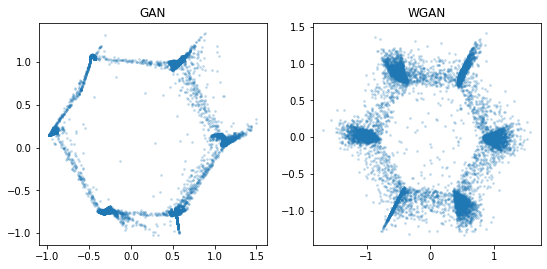

In [14]:
_, ax = plt.subplots(1, 2, figsize=(9,4))

gen_plot(ax[0], gan.netG)
ax[0].set(title="GAN")

gen_plot(ax[1], wgan.netG)
ax[1].set(title="WGAN")

plt.show()